# Credit Default Risk Modeling
This is a dataset of 

- SK_ID_CURR: ID of loan
- TARGET: 1 - defaulted / 0 - repayed
- EXT_SOURCES: Normalized score from external data source

The Task: Make predictions about approving a loan, will the borrower default? From a dataset of loan histories, finances and behaviors. 

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    if (PROJECT_ROOT.parent / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise FileNotFoundError(
            "Run this notebook from the P4 project root or the notebooks folder."
        )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

index_cols = ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index", "DAYS_ID_PUBLISH"]

from src.functions import *

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 10)

# csv_to_pkl()


In [2]:
from src.functions import *


In [3]:
df_train, df_test = get_merged_dataframe(debug=False, load=True)

del df_test

********************
LOAD MODE
LOADING THE PREVIOUS MERGED DATAFRAME
********************
final merged dataframe shape: (356254, 496)


# Model
Build several models and see which one performs the best. After finding the best model, turning his hyperparameters
## Split into X and y

In [4]:
X = df_train.loc[:,df_train.columns!='TARGET']
y = df_train.loc[:,'TARGET']

# saving memory
del df_train

### Split into test and training sets
Split the X and y sets into training and test sets.

In [5]:
#Seperate train and test data
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = 0.3,
                                                    random_state=RND_SEED,
                                                    stratify=y) #Same proportion of each target class in both the training and test sets.

# Use 20% of the training set during cross validation. The data has the same distribution.
debug = True  # Keep enabled for local hardware limits

# saving memory
#del X, y

## Features Selection

### Correlated Variables
Collinear variables are variables that are correlated with each another. When we have these features in the input feature set, we have multicollinearity. This can decrease model interpretability, we do not want this.

In [6]:
# Get a set of correlated features, based on threshold correlation of 0.85
drop_features = correlatedFeatures(X_train, y_train, threshold = 0.85)

#sorted(drop_features)

print(len(drop_features), "columns are dropped")

# Remove the correlated features
X_train.drop(columns=drop_features, inplace = True)
X_test.drop(columns=drop_features, inplace = True)

96 columns are dropped


## Find Best Model
### Build the Pipeline

- Missing values:
    - One Hot Encode categories and discrete features will be filled by the mode (median) value. 
    - Continous features will be filled by the mean value.
- Normalized Data:
    - MinMax
- Imbalanced Data: We tested 3 differents methods to resample our data and use the best one:
    - SMOTE (Best) / Oversampling / Downsampling

In [7]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Step1 - impute missing values
    ('scaler', MinMaxScaler(feature_range=(0,1))), # Step2 - normalize data
    ('sampler', SMOTE(random_state=RND_SEED)), # Step3 - resample data
    ('clf', None) # Step4 - classification
])

balanced_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Step1 - impute missing values
    ('scaler', MinMaxScaler(feature_range=(0,1))), # Step2 - normalize data
    ('clf', None) # Step4 - classification
])
#pipeline.steps

### Evaluate Baseline Models

********************
SAMPLED MODE
ONLY 20.0% OF THE DATA IS USED
THE REDUCED DATA HAVE THE SAME TARGET DISTRIBUTION
********************
DecisionTreeClassifier(random_state=7)
fit_time mean: 44.147 std: 9.2036
score_time mean: 0.403 std: 0.0769
test_score mean: 0.539 std: 0.007
AdaBoostClassifier(random_state=7)
fit_time mean: 156.991 std: 26.7772
score_time mean: 1.058 std: 0.2288
test_score mean: 0.673 std: 0.0111


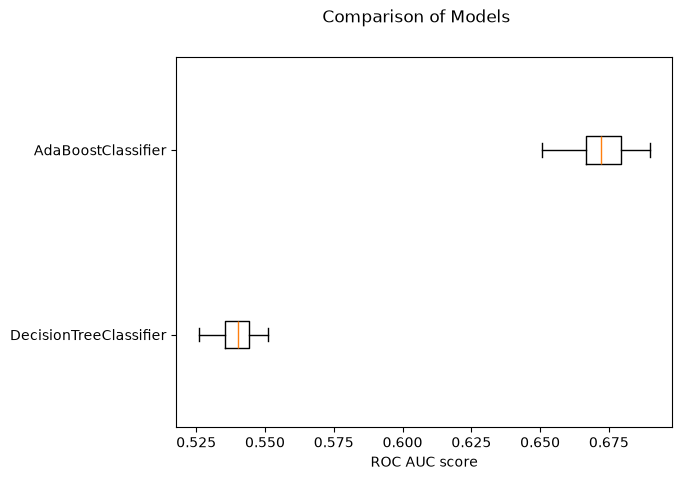

In [8]:
simple_vs_complex_model = []
simple_vs_complex_model.append(DecisionTreeClassifier(random_state=RND_SEED))
#The base estimator from which the boosted ensemble is built. If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.
simple_vs_complex_model.append(AdaBoostClassifier(random_state=RND_SEED))

results, names = evaluate_models(X_train, y_train, simple_vs_complex_model, pipeline, debug=debug)
compare_models(results, names)

In [9]:
results

[array([0.53041781, 0.53433385, 0.54320837, 0.53991988, 0.54444397,
        0.55121827, 0.54449012, 0.54069937, 0.52598516, 0.53929527]),
 array([0.67992622, 0.66323741, 0.6880509 , 0.68987445, 0.66905498,
        0.67316477, 0.66602217, 0.67125551, 0.67784575, 0.65076875])]

********************
SAMPLED MODE
ONLY 20.0% OF THE DATA IS USED
THE REDUCED DATA HAVE THE SAME TARGET DISTRIBUTION
********************
LogisticRegression(max_iter=5000, random_state=7)
fit_time mean: 66.384 std: 18.3653
score_time mean: 0.525 std: 0.1549
test_score mean: 0.736 std: 0.0132
KNeighborsClassifier()
fit_time mean: 14.593 std: 2.92
score_time mean: 18.955 std: 4.0964
test_score mean: 0.577 std: 0.0159
DecisionTreeClassifier(random_state=7)
fit_time mean: 48.299 std: 9.7071
score_time mean: 0.476 std: 0.1537
test_score mean: 0.539 std: 0.007
GaussianNB()
fit_time mean: 16.493 std: 3.5185
score_time mean: 0.625 std: 0.2542
test_score mean: 0.532 std: 0.0082
MLPClassifier(max_iter=500, random_state=7)
fit_time mean: 492.483 std: 98.138
score_time mean: 0.562 std: 0.1217
test_score mean: 0.635 std: 0.0138
AdaBoostClassifier(random_state=7)
fit_time mean: 143.709 std: 25.0795
score_time mean: 0.987 std: 0.2426
test_score mean: 0.673 std: 0.0111
HistGradientBoostingClassifier(ra

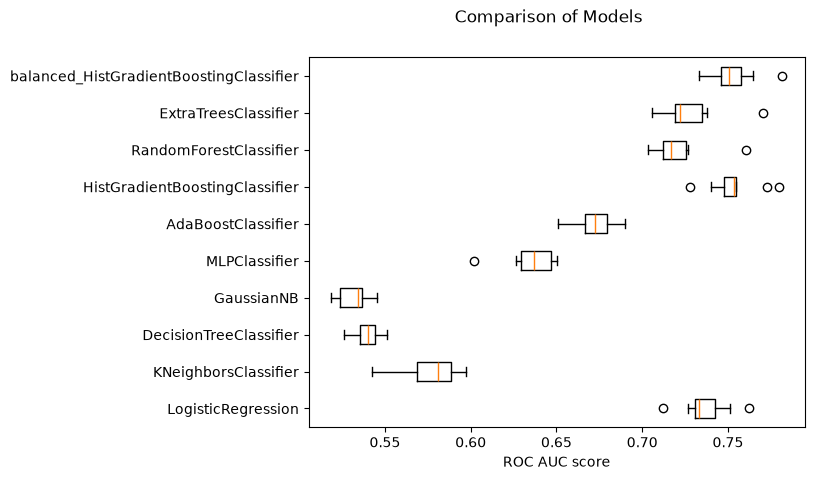

In [10]:
models = []
models.append(LogisticRegression(max_iter=5000, random_state=RND_SEED)) # do not converge otherwise
models.append(KNeighborsClassifier())
models.append(DecisionTreeClassifier(random_state=RND_SEED))
models.append(GaussianNB())
models.append(MLPClassifier(max_iter=500, random_state=RND_SEED)) # do not converge otherwise (need to be confirmed if 500 is enough)

ensembles = []
ensembles.append(AdaBoostClassifier(random_state=RND_SEED))
ensembles.append(HistGradientBoostingClassifier(random_state=RND_SEED))
ensembles.append(RandomForestClassifier(random_state=RND_SEED))
ensembles.append(ExtraTreesClassifier(random_state=RND_SEED))

# Balanced models put a weight on the imbalanced data, HistGradientBoostingClassifier has native support for missing values (NaNs).
balanced_models = []
balanced_models.append(HistGradientBoostingClassifier(class_weight='balanced', random_state=RND_SEED))

results, names = evaluate_models(X_train, y_train, models+ensembles, pipeline, debug=debug)
balanced_results, balanced_names = evaluate_models(X_train, y_train, balanced_models, balanced_pipeline, debug=debug)

balanced_names = list(map(lambda s: 'balanced_'+s, balanced_names))

compare_models(results+balanced_results, names+balanced_names)

### Best Model

Confusion matrix:
[[61844 22962]
 [ 2463  4984]]

ROC AUC: 0.6992518229926149

Classification report:
              precision    recall  f1-score   support

     repayed       0.96      0.73      0.83     84806
   defaulted       0.18      0.67      0.28      7447

    accuracy                           0.72     92253
   macro avg       0.57      0.70      0.56     92253
weighted avg       0.90      0.72      0.79     92253



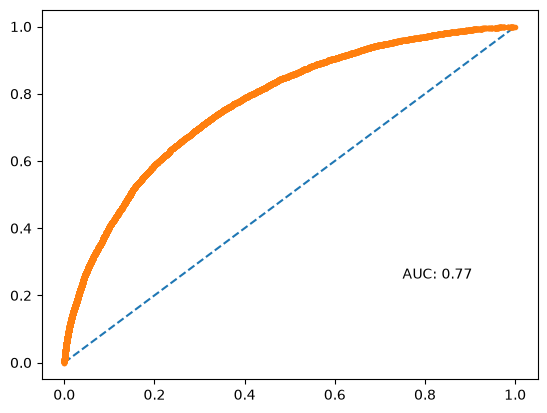

In [11]:
best_model = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(0,1))), # Step2 - normalize data
    ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RND_SEED)) # Step4 - classification
])

best_model.fit(X_train, y_train)

model_performance(best_model, X_test, y_test)

In [13]:
#selected_features

In [14]:
selected_features, cv_results = rfecv_selection(X_train, y_train, 1, 5, debug=debug)

********************
SAMPLED MODE
ONLY 20.0% OF THE DATA IS USED
THE REDUCED DATA HAVE THE SAME TARGET DISTRIBUTION
********************
Fitting estimator with 399 features.
Fitting estimator with 394 features.
Fitting estimator with 389 features.
Fitting estimator with 384 features.
Fitting estimator with 379 features.
Fitting estimator with 374 features.
Fitting estimator with 369 features.
Fitting estimator with 364 features.
Fitting estimator with 359 features.
Fitting estimator with 354 features.
Fitting estimator with 349 features.
Fitting estimator with 344 features.
Fitting estimator with 339 features.
Fitting estimator with 334 features.
Fitting estimator with 329 features.
Fitting estimator with 324 features.
Fitting estimator with 319 features.
Fitting estimator with 314 features.
Fitting estimator with 309 features.
Fitting estimator with 304 features.
Fitting estimator with 299 features.
Fitting estimator with 294 features.
Fitting estimator with 289 features.
Fitting esti

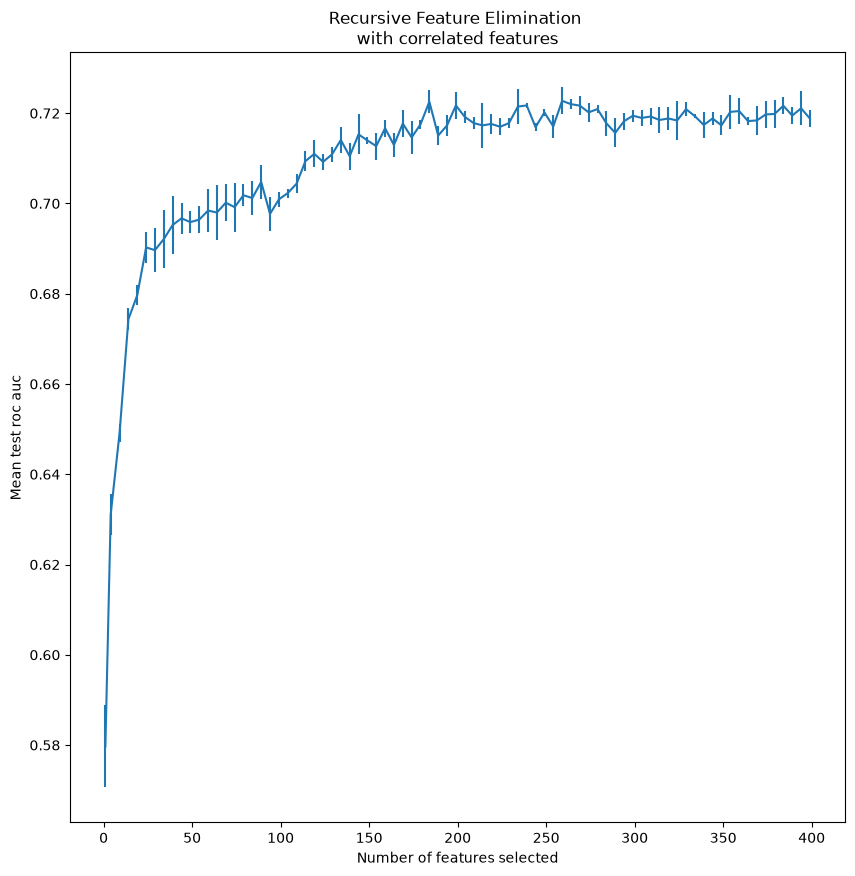

In [15]:
display_rfecv(1, 5, X_train.shape[1], cv_results.cv_results_)

## Permutation Importance

In [20]:
from sklearn.inspection import permutation_importance

#result = permutation_importance(best_model, X_train, y_train, n_repeats=10, random_state=RND_SEED, n_jobs=3)
result_test = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=3, max_samples=3000, random_state=RND_SEED, n_jobs=3)

In [23]:
for i in result_test.importances_mean.argsort()[::-1]:
    #if result.importances_mean[i] - 2 * result.importances_std[i] > 0:
    if round(result_test.importances_mean[i],3) != 0:
        print(f"{X.columns[i]:<8} "
            f"{result_test.importances_mean[i]:.3f}"
            f" +/- {result_test.importances_std[i]:.3f}")

FLAG_DOCUMENT_6 0.033 +/- 0.005
LIVE_REGION_NOT_WORK_REGION 0.009 +/- 0.002
DAYS_BIRTH 0.004 +/- 0.004
FLAG_DOCUMENT_5 0.003 +/- 0.003
FLAG_DOCUMENT_8 0.002 +/- 0.001
FLAG_DOCUMENT_4 0.002 +/- 0.002
prev_NAME_SELLER_INDUSTRY_Tourism_max 0.001 +/- 0.001
prev_CHANNEL_TYPE_Regional_Local_max -0.001 +/- 0.002
AMT_CREDIT -0.001 +/- 0.001
prev_NAME_YIELD_GROUP_high_max -0.001 +/- 0.001
prev_NAME_SELLER_INDUSTRY_Industry_max -0.002 +/- 0.001
AMT_ANNUITY -0.002 +/- 0.000
prev_PRODUCT_COMBINATION_Cash_X_Sell_high_max -0.003 +/- 0.001
REGION_POPULATION_RELATIVE -0.003 +/- 0.001
NONLIVINGAREA_AVG -0.003 +/- 0.001
prev_NAME_GOODS_CATEGORY_Clothing_and_Accessories_max -0.003 +/- 0.001
prev_NAME_SELLER_INDUSTRY_Clothing_max -0.003 +/- 0.000
prev_CHANNEL_TYPE_Stone_max -0.003 +/- 0.001
bureau_AMT_CREDIT_SUM_DEBT_sum -0.003 +/- 0.001
WALLSMATERIAL_MODE_Monolithic -0.003 +/- 0.001
FLOORSMAX_AVG -0.003 +/- 0.001
REG_CITY_NOT_LIVE_CITY -0.003 +/- 0.001
prev_NAME_GOODS_CATEGORY_Homewares_max -0.003 +/- 0.

In [24]:
# for i in result.importances_mean.argsort()[::-1]:
#     #if result.importances_mean[i] - 2 * result.importances_std[i] > 0:
#     if round(result.importances_mean[i],3) != 0:
#         print(f"{X.columns[i]:<8} "
#             f"{result.importances_mean[i]:.3f}"
#             f" +/- {result.importances_std[i]:.3f}")

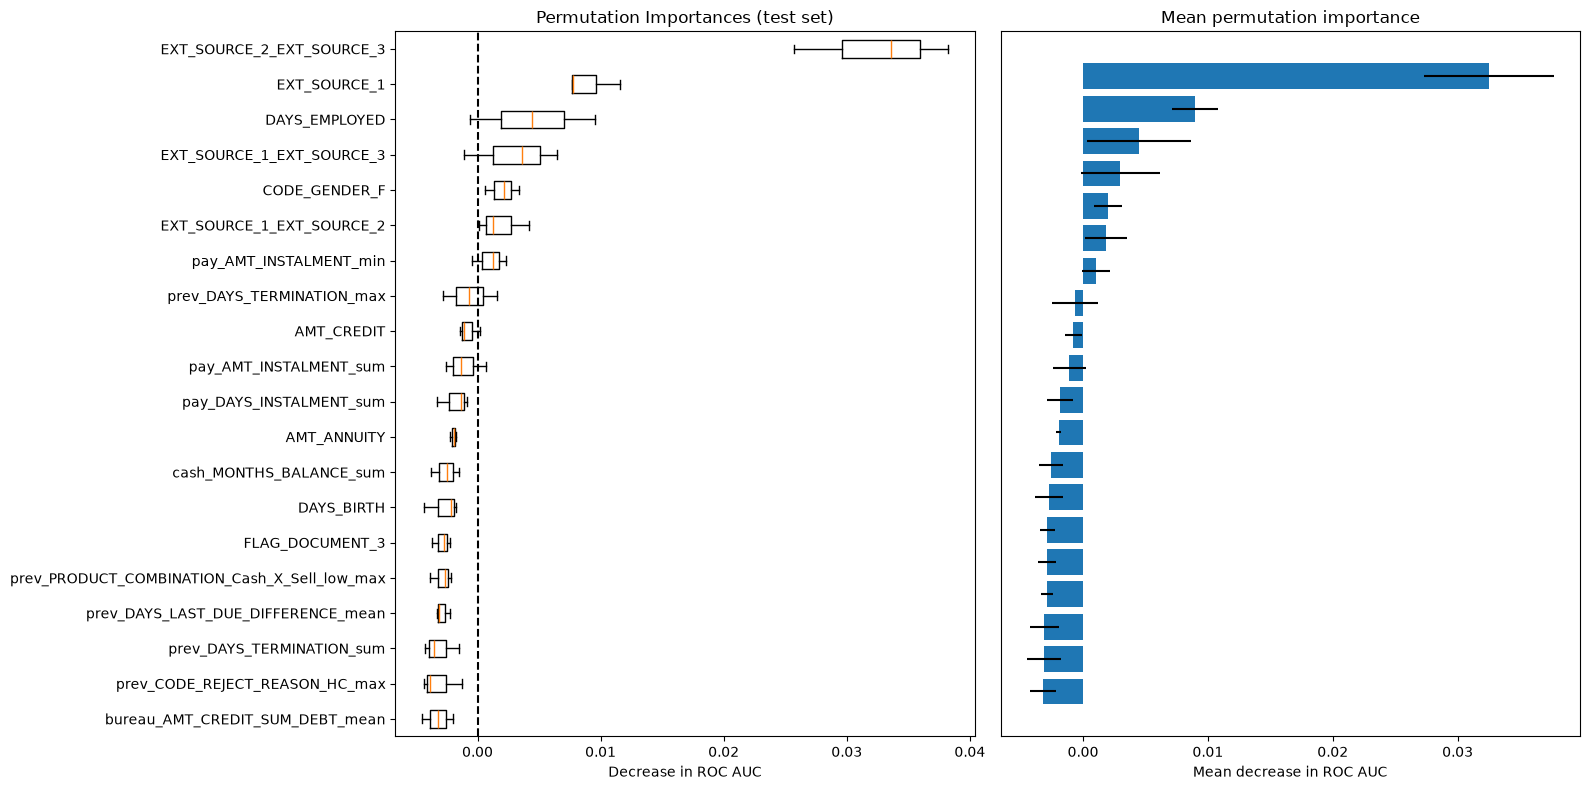

In [35]:
sorted_importances_idx = result_test.importances_mean.argsort()

top_idx = sorted_importances_idx[-20:]
feature_names = X_test.columns[top_idx].tolist()

importances = pd.DataFrame(
    result_test.importances[top_idx].T,
    columns=feature_names,
)

fig, (ax,ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax.boxplot(
    result_test.importances[top_idx].T,
    orientation="horizontal",
    tick_labels=feature_names,
)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in ROC AUC")

ax2.barh(
    feature_names,
    result_test.importances_mean[top_idx],
    xerr=result_test.importances_std[top_idx],
)

# Remove duplicated feature labels from the second graph
ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)

ax2.set_title("Mean permutation importance")
ax2.set_xlabel("Mean decrease in ROC AUC")


fig.tight_layout()
plt.show()

In [38]:
# sorted_importances_idx = result.importances_mean.argsort()
# importances = pd.DataFrame(
#     result.importances[sorted_importances_idx][-30:-1].T,
#     columns=X.columns[sorted_importances_idx][-30:-1],
# )
# fig, (ax,a2) = plt.subplots(1, 2, figsize=(16, 8))
# ax.boxplot(
#     result.importances[sorted_importances_idx][-30:-1].T,
#     vert=False,
#     labels=X.columns[sorted_importances_idx][-30:-1],
# )
# ax.set_title("Permutation Importances (test set)")
# ax.axvline(x=0, color="k", linestyle="--")
# ax.set_xlabel("Decrease in accuracy score")
# fig.tight_layout()
# plt.show()

Confusion matrix:
[[63083 21723]
 [ 2515  4932]]

ROC AUC: 0.7030653918700966

Classification report:
              precision    recall  f1-score   support

     repayed       0.96      0.74      0.84     84806
   defaulted       0.19      0.66      0.29      7447

    accuracy                           0.74     92253
   macro avg       0.57      0.70      0.56     92253
weighted avg       0.90      0.74      0.79     92253



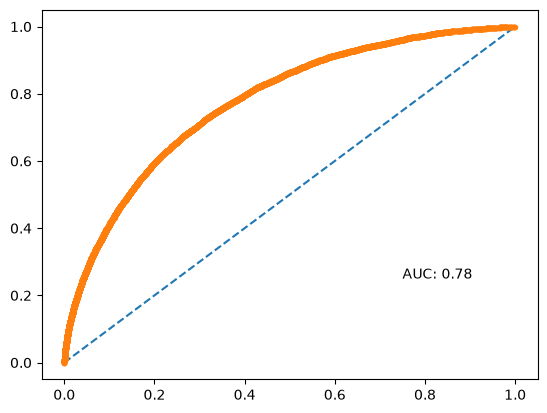

In [37]:
best_random_model= Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                            l2_regularization=180.55006971954802,
                            learning_rate=0.04955815713711741,
                            max_depth=74, max_iter=894,
                            max_leaf_nodes=38,
                            min_samples_leaf=5,
                            random_state=RND_SEED))])

best_random_model.fit(X_train, y_train)

model_performance(best_random_model, X_test, y_test)

## Optional Hyperparameter Tuning

Exhaustive grid search was omitted because of local computational constraints. A limited randomized search can be enabled when additional computing resources are available.

In [ ]:
# random_search = get_hyperparameters_random(X_train, y_train, debug=debug)

In [ ]:
#grid_search = get_hyperparameters(X_train, y_train, debug=debug)
##random_search = get_hyperparameters_random(X_train, y_train, debug=debug)


##{'histgradientboostingclassifier__l2_regularization': 1.5, 'histgradientboostingclassifier__learning_rate': 0.01, 'histgradientboostingclassifier__max_depth': 75, 'histgradientboostingclassifier__max_iter': 1000}

#### baseline
##{'histgradientboostingclassifier__l2_regularization': 1.5, 'histgradientboostingclassifier__learning_rate': 0.1, 'histgradientboostingclassifier__max_depth': 25, 'histgradientboostingclassifier__max_iter': 1200}

In [ ]:
#estimator = grid_search.best_estimator_
#estimator.fit(X_train, y_train)

##X_test = pd.DataFrame(MinMaxScaler().fit_transform(X_test), columns=X_test.columns)
#predictions = estimator.predict(X_test)

In [ ]:
# model_performance(estimator, X_test, y_test)

In [ ]:
# estimator = random_search.best_estimator_
# estimator.fit(X_train, y_train)

# #X_test = pd.DataFrame(MinMaxScaler().fit_transform(X_test), columns=X_test.columns)
# predictions = estimator.predict(X_test)
# model_performance(estimator, X_test, y_test)

In [ ]:
# model_performance(estimator, X_test, y_test)

In [ ]:
# lr = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')), # Step1 - impute missing values
#     ('scaler', MinMaxScaler(feature_range=(0,1))), # Step2 - normalize data
#     ('sampler', SMOTE(random_state=RND_SEED)), # Step3 - resample data
#     ('clf', LogisticRegression(max_iter=5000, random_state=RND_SEED)) # Step4 - classification
# ])

# lr.fit(X_train, y_train)

# model_performance(lr, X_test, y_test)

In [ ]:
# logisticRegressionSummary(lr['clf'], X_test.columns)

## SHAP

In [39]:
import shap

# X = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)

# model = HistGradientBoostingClassifier(class_weight='balanced', random_state=RND_SEED)

# #Seperate train and test data
# X_train, X_test, y_train, y_test = train_test_split(X, 
#                                                     y,
#                                                     test_size = 0.9,
#                                                     random_state=RND_SEED)



In [40]:
# model.fit(X_train, y_train)

In [44]:
# Explain only a small test sample
X_shap = X_test.sample(
    n=min(200, len(X_test)),
    random_state=RND_SEED,
)


# Extract fitted pipeline components
scaler = best_model.named_steps["scaler"]
model = best_model.named_steps["clf"]

# Apply the same transformation used during training
X_shap_scaled = pd.DataFrame(
    scaler.transform(X_shap),
    columns=X_shap.columns,
    index=X_shap.index,
)

# Explain the tree model, not the complete pipeline
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap_scaled)

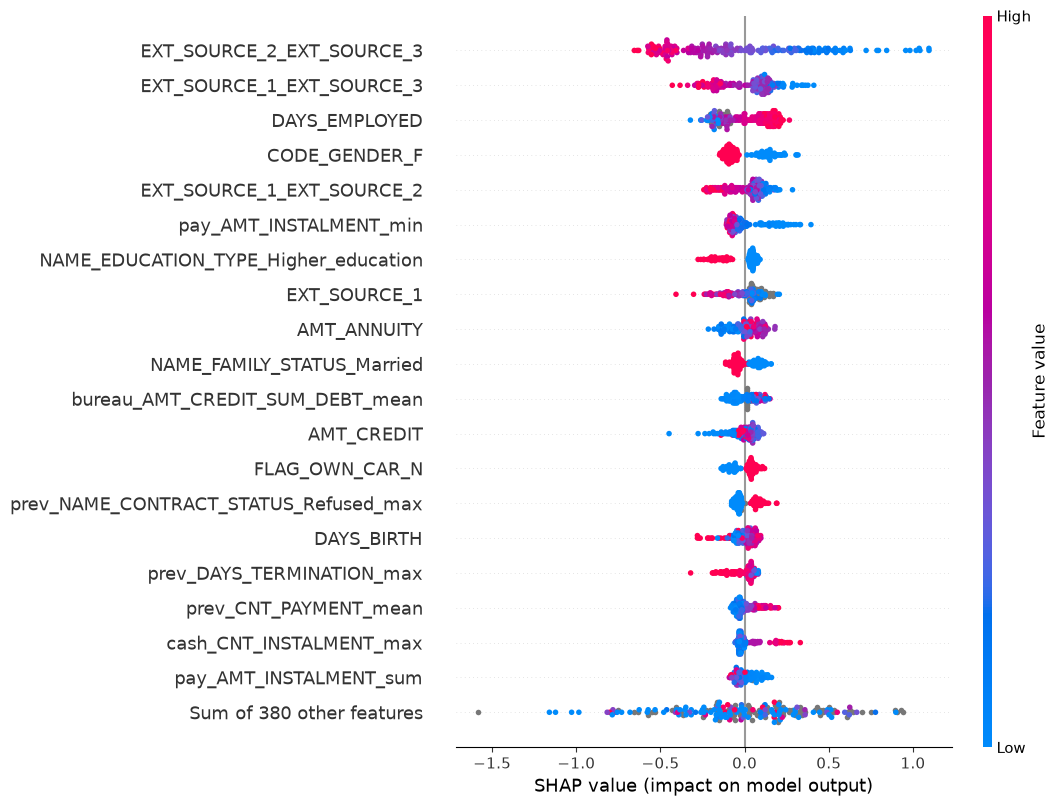

In [46]:
shap.plots.beeswarm(
    shap_values,
    max_display=20,
)

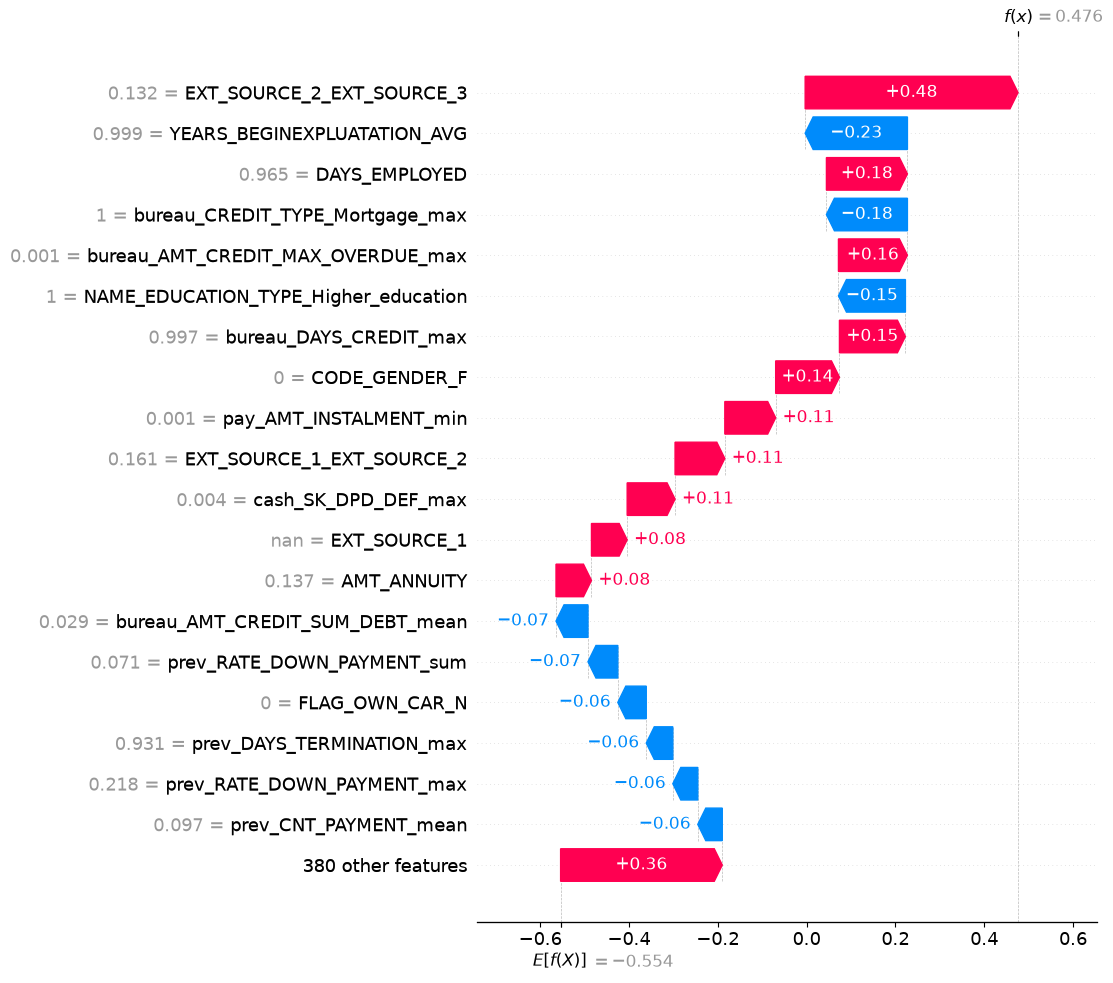

In [47]:
shap.plots.waterfall(
    shap_values[0],
    max_display=20,
)

# NOT USED
## Imbalanced Data / Method
We decide to resample our data, we used 3 differents methods:
- Oversampling
- Downsampling
- SMOTE

Our data are imbalanced, there are about 10 times more repayed than defaulted

### decisionTreeSummary

In [ ]:
# decisionTreeSummary(model, X.columns)

In [ ]:
# ### print result on 10% of the data

# models = [
#     DecisionTreeClassifier(random_state=RND_SEED), 
#     LogisticRegression(solver='lbfgs', multi_class='auto', max_iter=5000, random_state=RND_SEED), 
#     RandomForestClassifier(random_state=RND_SEED)
#          ]

# from itertools import repeat


# def select_resampling_method(methods, models, X, y):
#     # Rescale the data
#     scaler = MinMaxScaler(feature_range=(0,1))
#     X_ = scaler.fit_transform(X)

#     # Convert X back to a Pandas DataFrame, for convenience
#     X = pd.DataFrame(X_, index=X.index, columns=X.columns)
        
#     for method in methods:
#         test_size = 0.33
#         X_train, X_test, y_train, y_test = train_test_split(
#             X,
#             y,
#             test_size=test_size,
#             stratify=y,
#             random_state=RND_SEED,
#         )
#         X_train, y_train = resampling(X_train, y_train, method=method)

#         for model in models:
#             model.fit(X_train, y_train)
#             predictions = model.predict(X_test)
#             probabilities = model.predict_proba(X_test)[:, 1]
            
#             print(
#                 method,
#                 type(model).__name__,
#                 "Accuracy:",
#                 accuracy_score(y_test, predictions),
#                 "ROC AUC:",
#                 roc_auc_score(y_test, probabilities),
#             )      

# select_resampling_method(['downsampling', 'oversampling', 'SMOTE'], models, X_sample, y_sample)

In [ ]:
# ### Feature Importances: RFECV

# min_features_to_select=200
# step = 35
# n_features = X_train.shape[1]

# drop_features, selector = rfecv_selection(X_train, y_train, min_features_to_select, step, debug=debug)

# display_rfecv(min_features_to_select, step, n_features, selector.cv_results_)

# list(drop_features)

In [ ]:
# drop_features = ['NAME_TYPE_SUITE_Unaccompanied',
#  'NAME_INCOME_TYPE_Maternity_leave',
#  'NAME_HOUSING_TYPE_House_apartment',
#  'NAME_HOUSING_TYPE_Office_apartment',
#  'OCCUPATION_TYPE_Accountants',
#  'OCCUPATION_TYPE_Cooking_staff',
#  'OCCUPATION_TYPE_Core_staff',
#  'OCCUPATION_TYPE_Drivers',
#  'OCCUPATION_TYPE_HR_staff',
#  'OCCUPATION_TYPE_High_skill_tech_staff',
#  'OCCUPATION_TYPE_IT_staff',
#  'OCCUPATION_TYPE_Laborers',
#  'OCCUPATION_TYPE_Managers',
#  'OCCUPATION_TYPE_Private_service_staff',
#  'OCCUPATION_TYPE_Realty_agents',
#  'OCCUPATION_TYPE_Sales_staff',
#  'ORGANIZATION_TYPE_Culture',
#  'ORGANIZATION_TYPE_Electricity',
#  'ORGANIZATION_TYPE_Housing',
#  'ORGANIZATION_TYPE_Insurance',
#  'ORGANIZATION_TYPE_Medicine',
#  'ORGANIZATION_TYPE_Military',
#  'ORGANIZATION_TYPE_Other',
#  'ORGANIZATION_TYPE_Self_employed',
#  'ORGANIZATION_TYPE_Telecom',
#  'WALLSMATERIAL_MODE_Block',
#  'WALLSMATERIAL_MODE_Monolithic',
#  'EMERGENCYSTATE_MODE_Yes',
#  'AGE_GROUP_1',
#  'bureau_CREDIT_CURRENCY_currency_2_max',
#  'bureau_CREDIT_TYPE_Car_loan_max',
#  'bureau_CREDIT_TYPE_Consumer_credit_max',
#  'bureau_CREDIT_TYPE_Credit_card_max',
#  'bureau_CREDIT_TYPE_Interbank_credit_max',
#  'bureau_CREDIT_TYPE_Loan_for_purchase_of_shares_margin_lending__max',
#  'bureau_CREDIT_TYPE_Microloan_max',
#  'bureau_CREDIT_TYPE_Mortgage_max',
#  'bureau_DAYS_CREDIT_min',
#  'bureau_DAYS_CREDIT_mean',
#  'bureau_DAYS_CREDIT_ENDDATE_max',
#  'bureau_AMT_CREDIT_MAX_OVERDUE_max',
#  'bureau_AMT_CREDIT_SUM_DEBT_mean',
#  'bureau_AMT_CREDIT_SUM_OVERDUE_mean',
#  'prev_NAME_CONTRACT_TYPE_Consumer_loans_max',
#  'prev_WEEKDAY_APPR_PROCESS_START_MONDAY_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Buying_a_used_car_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Everyday_expenses_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Furniture_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Gasification_water_supply_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Hobby_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Journey_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Money_for_a_third_person_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Purchase_of_electronic_equipment_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Refusal_to_name_the_goal_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Repairs_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Urgent_needs_max',
#  'prev_NAME_CASH_LOAN_PURPOSE_Wedding_gift_holiday_max',
#  'prev_NAME_CONTRACT_STATUS_Canceled_max',
#  'prev_NAME_CONTRACT_STATUS_Unused_offer_max',
#  'prev_NAME_PAYMENT_TYPE_Cash_through_the_bank_max',
#  'prev_NAME_CLIENT_TYPE_Repeater_max',
#  'prev_NAME_GOODS_CATEGORY_Animals_max',
#  'prev_NAME_GOODS_CATEGORY_Audio_Video_max',
#  'prev_NAME_GOODS_CATEGORY_Auto_Accessories_max',
#  'prev_NAME_GOODS_CATEGORY_Clothing_and_Accessories_max',
#  'prev_NAME_GOODS_CATEGORY_Computers_max',
#  'prev_NAME_GOODS_CATEGORY_Consumer_Electronics_max',
#  'prev_NAME_GOODS_CATEGORY_Fitness_max',
#  'prev_NAME_GOODS_CATEGORY_Furniture_max',
#  'prev_NAME_GOODS_CATEGORY_Gardening_max',
#  'prev_NAME_GOODS_CATEGORY_Homewares_max',
#  'prev_NAME_GOODS_CATEGORY_Insurance_max',
#  'prev_NAME_GOODS_CATEGORY_Medical_Supplies_max',
#  'prev_NAME_GOODS_CATEGORY_Medicine_max',
#  'prev_NAME_GOODS_CATEGORY_Mobile_max',
#  'prev_NAME_GOODS_CATEGORY_Photo_Cinema_Equipment_max',
#  'prev_NAME_GOODS_CATEGORY_Sport_and_Leisure_max',
#  'prev_NAME_PORTFOLIO_Cars_max',
#  'prev_CHANNEL_TYPE_Channel_of_corporate_sales_max',
#  'prev_CHANNEL_TYPE_Contact_center_max',
#  'prev_CHANNEL_TYPE_Regional_Local_max',
#  'prev_NAME_SELLER_INDUSTRY_Industry_max',
#  'prev_NAME_SELLER_INDUSTRY_Jewelry_max',
#  'prev_PRODUCT_COMBINATION_Card_Street_max',
#  'prev_PRODUCT_COMBINATION_Card_X_Sell_max',
#  'prev_PRODUCT_COMBINATION_Cash_max',
#  'prev_PRODUCT_COMBINATION_Cash_X_Sell_high_max',
#  'prev_PRODUCT_COMBINATION_Cash_X_Sell_low_max',
#  'prev_PRODUCT_COMBINATION_POS_household_with_interest_max',
#  'prev_PRODUCT_COMBINATION_POS_household_without_interest_max',
#  'prev_PRODUCT_COMBINATION_POS_other_with_interest_max',
#  'prev_PRODUCT_COMBINATION_POS_others_without_interest_max',
#  'prev_AMT_ANNUITY_max',
#  'prev_AMT_ANNUITY_sum',
#  'prev_AMT_CREDIT_max',
#  'prev_AMT_CREDIT_min',
#  'prev_RATE_DOWN_PAYMENT_mean',
#  'prev_RATE_DOWN_PAYMENT_max',
#  'prev_RATE_DOWN_PAYMENT_min',
#  'prev_DAYS_LAST_DUE_DIFFERENCE_max',
#  'pay_AMT_PAYMENT_min',
#  'cash_NAME_CONTRACT_STATUS_Demand_max',
#  'cash_NAME_CONTRACT_STATUS_Returned_to_the_store_max',
#  'cash_LATE_PAYMENT_max',
#  'cash_MONTHS_BALANCE_max']


# print(len(drop_features), "columns are dropped")
# # Remove the correlated features
# X_train.drop(columns=drop_features, inplace = True)
# X_test.drop(columns=drop_features, inplace = True)